# RFM Analysis

**Objectives**

Segment customers based on RFM (Recency, Frequency, Monetary) scores into interpretable groups to provide customer insight.

**Key Output**

- Customer segmentation data stored in `data/analysis/rfm.parquet` suitable for visualisation in PowerBI. 
- Descriptions and interpretations for each customer segment. 

**Data**
Data is queried from `Sales/data/sqliteDB/sales.db` using `Q_rfm` query in `scripts/SQL_queries.py`. This gives us a table with the following factors:
- `CustomerId`: unique Id assigned to each customer. 
- `recency`: number of days since last purchase. 
- `frequency`: number of orders.
- `monetary_value`: average purchase value per order.
- `tenure`: number of days since first order. 

The query `Q_rfm` contains a subquery called `Qsub_Order_Data` which filters:  
- All orders with `C` in the invoice number. These entries correspond to cancellations in order. 
- Entries with negative or 0 revenue. These entries correspond to errors.
- Orders with CategoryLabel being NULL. In `1_create_categories`, categories corresponding to system logs (broken stock, damages, etc) are given NULL entry. Note here that valid entries with no descriptions are given 'NO DESCRIPTION'. 

In [86]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

np.random.seed(42)

import seaborn as sns
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA as pca
from sklearn.cluster import KMeans

import warnings 
warnings.filterwarnings("ignore", category=RuntimeWarning) # Suppress harmless divide-by-zero warnings from scikit-learn distance computations

In [87]:
# Query RFM Data
sys.path.insert(0, str(Path.cwd().parents[0])) # add project root to sys path
from scripts.SQL_queries import main as query

rfm_df = query(rfm = True)
rfm_df.head()

,CustomerID,recency,frequency,monetary_value,tenure
0,NaN,0.0,1371,1262.156229,373.0
1,12346.0,325.0,1,77183.600000,325.0
2,12347.0,2.0,7,638.152857,367.0
3,12348.0,75.0,4,375.210000,358.0
4,12349.0,18.0,1,1758.070000,18.0


## Exploratory Data Analysis

The following was observed in the data:
- Minimal NAs in data and no negative values (all values should be non negative).
- Heavy concentration of low monetary value (revenue per orders) and frequency (orders per exposure time). 
- Most customers purchased within the last 100 days, with a steady count of customers for greater last purchase days. Indicates a approximate churn rate at the 100 day mark. 


In [88]:
np_customer = rfm_df['CustomerID'].unique().shape[0]

### Invalid Values

Problematic values in the data include the usual NAs as well as negative values since 'R', 'F' and 'M' must all be non negative.

In [89]:
# Obtain customerID with NA values
na_mask = rfm_df.isna().any(axis=1)
print("NAs: \n" +str(rfm_df[na_mask]))

# # Check for negative values
mask = (rfm_df['recency'] < 0) + (rfm_df['frequency'] < 0) + (rfm_df['monetary_value'] < 0) + (rfm_df['tenure'] < 0)
print("Negative Entries: \n" + str(rfm_df[mask]))


NAs: 
   CustomerID  recency  frequency  monetary_value  tenure
0         NaN      0.0       1371     1262.156229   373.0
Negative Entries: 
Empty DataFrame
Columns: [CustomerID, recency, frequency, monetary_value, tenure]
Index: []


We see that only two rows have NA entries. The first being a NaN in customerID and the second seems to be an issue with the frequency which traces back to the original dataset. 

### Variable Distribution

The next plot shows the distribution of each variable.

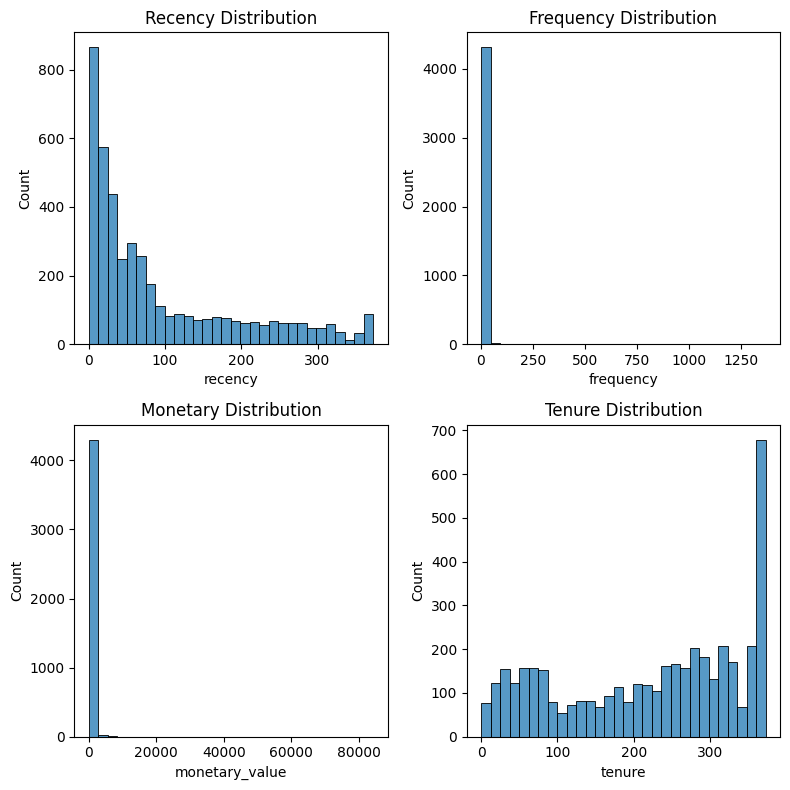

In [90]:
def plot_hist_rfm(rfm_df):
    fig, ax = plt.subplots(2,2, figsize=(8,8))

    sns.histplot(rfm_df['recency'], bins=30, ax=ax[0,0])
    sns.histplot(rfm_df['frequency'], bins=30, ax=ax[0,1])
    sns.histplot(rfm_df['monetary_value'], bins=30, ax=ax[1,0])
    sns.histplot(rfm_df['tenure'], bins=30, ax=ax[1,1])

    ax[0,0].set_title('Recency Distribution')
    ax[0,1].set_title('Frequency Distribution')
    ax[1,0].set_title('Monetary Distribution')
    ax[1,1].set_title('Tenure Distribution')

    plt.tight_layout()
    plt.show()

plot_hist_rfm(rfm_df)

We observe the following:
- Recency histogram shows that a significant proportion of customer's last purchase occurs within the most recent 100 days. 
- The skewness of the frequency histogram shows that most customers have lower orders per day. 
- The skewness of the monetary histogram indicates majority lower revenue per orders. 

The final plot is a 3D scatter plot showing recency, frequency and monetary value. 

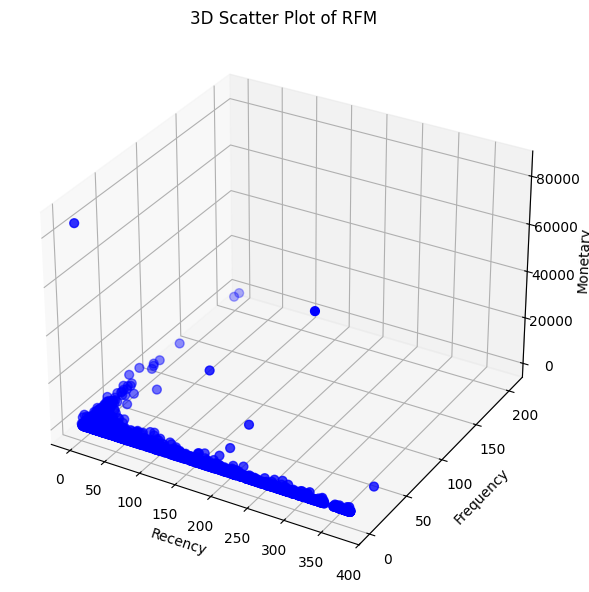

In [91]:
def plot_3D_rfm(rfm_df: pd.DataFrame):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')
    
    # Remove NAs for plotting
    rfm_df = rfm_df.dropna()

    # Plot with cluster coloring if available
    if 'KMeans_Cluster' in rfm_df.columns:
        clusters = sorted(rfm_df['KMeans_Cluster'].unique().astype(int))
        cmap = plt.colormaps.get_cmap('tab10')

        for i, cluster in enumerate(clusters):
            subset = rfm_df[rfm_df['KMeans_Cluster'] == cluster]

            ax.scatter(
                subset['recency'],
                subset['frequency'],
                subset['monetary_value'],
                color=cmap(i / len(clusters)),
                label=f'Cluster {cluster}',
                s=40
            )

        ax.legend(title='KMeans Cluster')

    # Plot without cluster coloring if not available
    else:
        ax.scatter(
            rfm_df['recency'],
            rfm_df['frequency'],
            rfm_df['monetary_value'],
            color='blue',
            s=40
        )

    # Plot configurations
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    ax.set_title('3D Scatter Plot of RFM')

    plt.tight_layout()
    plt.show()
    
plot_3D_rfm(rfm_df)


## Qunatile Scores

We segment customers based on RFM scores. The variable scores assigned to each customer are based on the quantiles the variable are in. 

### Calculating Quantiles 



In [92]:
# Prepare data
rfm_qdf = rfm_df.copy()

# Remove invalid customers
rfm_qdf = rfm_qdf.dropna(subset=['CustomerID'])


# Calculate qunatile scores
def qcut_rfm(rfm_qdf:pd.DataFrame, var:str, quantiles_list:list):
    
    # Add small noise to break ties
    noise = np.random.normal(0, 1e-9, size=rfm_qdf.shape[0])
    var_noise = rfm_qdf[var] + noise
    
    # Create ranks
    rfm_qdf[var+'_rank'] = var_noise.rank(
        method='average', 
        ascending = (True if var=='recency' else False) 
        )

    # Crate quantile scores based on ranks
    rfm_qdf[var+'_score'] = pd.qcut(
        x = rfm_qdf[var+'_rank'],
        q = quantiles_list,
        labels = list(range(len(quantiles_list)))[1:]
        )
    
    # only keep final scores
    rfm_qdf.drop(var, axis=1, inplace=True)
    rfm_qdf.drop(var+'_rank', axis=1, inplace=True)
    
    return rfm_qdf


quantiles_list = [0.0,0.20,0.4,0.6,0.8,1.0]

for var in ['recency','frequency','monetary_value','tenure']:
    rfm_qdf = qcut_rfm(rfm_qdf, var,quantiles_list)

### Create Segements

In [93]:
def assign_segment(rfm_df:pd.DataFrame):
    """Assign segments to each customer."""
    rfm_df['Segment'] = 'Other'

    # Champions
    rfm_df.loc[
        (rfm_df['recency_score'] >= 4) &
        (rfm_df['frequency_score'] >= 4) &
        (rfm_df['monetary_value_score'] >= 4),
        'Segment'
    ] = 'Champions'

    # New customers
    rfm_df.loc[
        (rfm_df['recency_score'] >= 4) &
        (rfm_df['frequency_score'] <= 2) &
        (rfm_df['tenure_score'] == 1),
        'Segment'
    ] = 'New Customers'

    # Loyal customers
    rfm_df.loc[
        (rfm_df['frequency_score'] >= 4) &
        (rfm_df['recency_score'] >= 3),
        'Segment'
    ] = 'Loyal Customers'

    # Potential loyalists
    rfm_df.loc[
        (rfm_df['frequency_score'] == 3) &
        (rfm_df['recency_score'] >= 3),
        'Segment'
    ] = 'Potential Loyalists'

    # High value at risk
    rfm_df.loc[
        (rfm_df['recency_score'] <= 2) &
        (rfm_df['frequency_score'] >= 3) &
        (rfm_df['monetary_value_score'] >= 4),
        'Segment'
    ] = 'High Value at Risk'

    # At risk
    rfm_df.loc[
        (rfm_df['recency_score'] <= 2) &
        (rfm_df['frequency_score'] >= 3),
        'Segment'
    ] = 'At Risk'

    # Hibernating
    rfm_df.loc[
        (rfm_df['recency_score'] <= 2) &
        (rfm_df['frequency_score'] <= 2),
        'Segment'
    ] = 'Hibernating'

    # Lost customers
    rfm_df.loc[
        (rfm_df['recency_score'] == 1) &
        (rfm_df['frequency_score'] <= 2) &
        (rfm_df['tenure_score'] >= 4),
        'Segment'
    ] = 'Lost'

    return rfm_df


rfm_seg_qdf = assign_segment(rfm_qdf)
rfm_seg_qdf


,CustomerID,recency_score,frequency_score,monetary_value_score,tenure_score,Segment
1,12346.0,5,4,1,2,Loyal Customers
2,12347.0,1,1,1,1,Hibernating
3,12348.0,4,2,3,1,New Customers
4,12349.0,2,4,1,5,At Risk
5,12350.0,5,5,3,2,Loyal Customers
...,...,...,...,...,...,...
4330,18280.0,5,4,4,3,Loyal Customers
4331,18281.0,5,5,5,4,Loyal Customers
4332,18282.0,1,3,5,4,At Risk
4333,18283.0,1,1,5,2,Hibernating


In [94]:
# Reshape to long format
customer_categories = (
    rfm_seg_qdf
        .columns.difference(
            ['CustomerID',
             'recency_score',
             'frequency_score',
             'monetary_value_score',
             'tenure_score']
            )
    )

rfm_seg_qdf = rfm_seg_qdf.melt(
    id_vars='CustomerID',
    value_vars=customer_categories,
    var_name='Customer_Segment',
    value_name='Is_Member'
)

# Save RFM with customer groups
OUT_DIR = '../data/analysis'
rfm_seg_qdf.to_parquet(OUT_DIR +"/rfm_segments.parquet")


## Clustering

We apply clustering algorithm to produce customer segments. 

- Features exhibit skew and differ in scale; log transformation and standardization were applied prior to clustering.
- Distance-based clustering (K-means) was chosen based on feature types and analytical goals.
- Number of clusters (N = 4) determined using distortion and inertia plots.
- A 3D visualization of clusters confirms they are well-separated and interpretable.


### Preprocessing

Exploratory analysis shows two customers with NA entries. This is negligible and can be dropped. 

Skewed data may cause issues for Kmeans clustering clustering since large values may distort groups. Furthermore, non spherical data could potentially be problematic for clustering. We therefore apply a sqrt, boxcox and log transform to normalise the data.

Since KMeans is a distance based algorithm, we apply also standard scaling. 

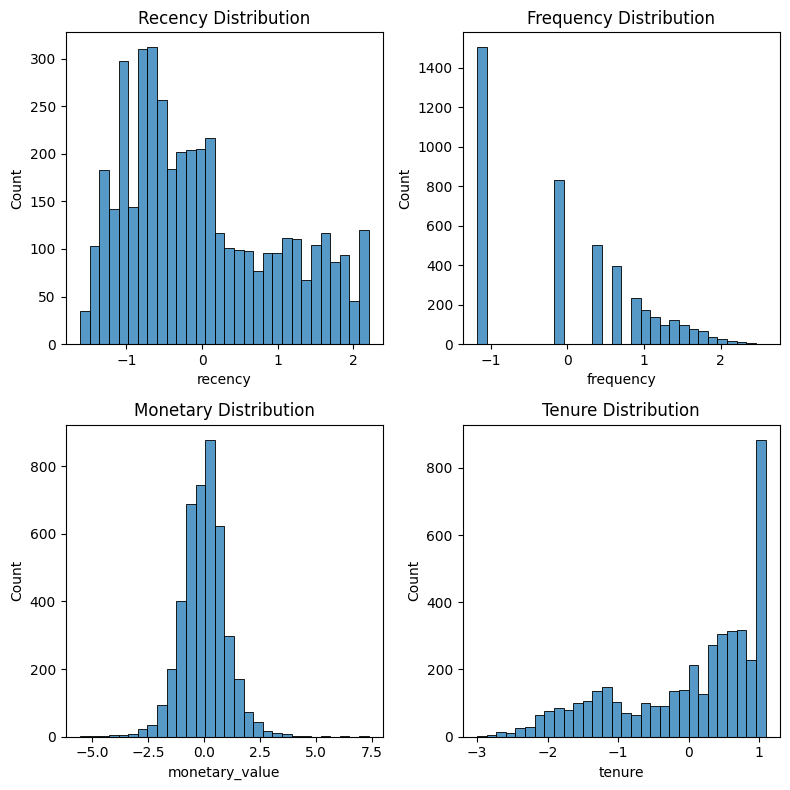

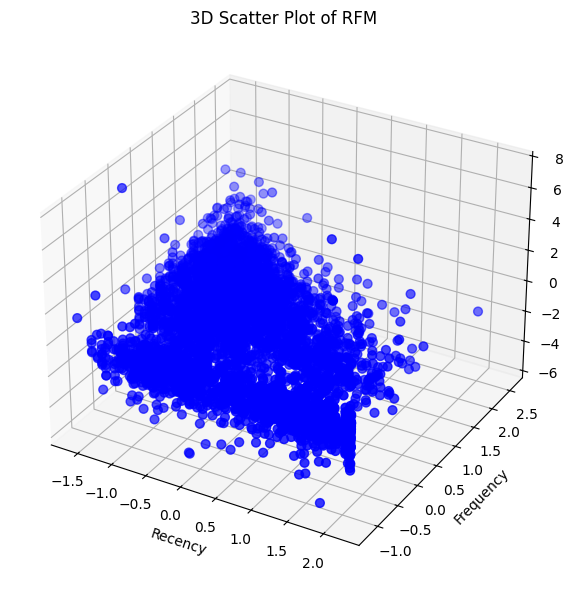

In [95]:
rfm_sdf = rfm_df.copy(deep=True)

# Remove NAs
rfm_sdf.dropna(inplace=True)

# Apply transformations to R, F, M
rfm_sdf['recency'] = np.sqrt(rfm_sdf['recency']) # srt(x)
rfm_sdf['frequency'], lamb = boxcox(rfm_sdf['frequency']) # boxcox
rfm_sdf['monetary_value'] = np.log(rfm_sdf['monetary_value']+1) # log(1+x)
rfm_sdf['tenure'] = np.sqrt(rfm_sdf['tenure']) # srt(x)

# Apply standard scaling 
scaler = StandardScaler()
rfm_sdf[['recency','frequency','monetary_value','tenure']] = (
    scaler.fit_transform(
        rfm_sdf[['recency','frequency','monetary_value','tenure']])
    )

plot_hist_rfm(rfm_sdf)
plot_3D_rfm(rfm_sdf)


### Determining Number of Clusters

Number of clusters are determined by examining the distortion and inertia plots.

Number of rows of zeros:4


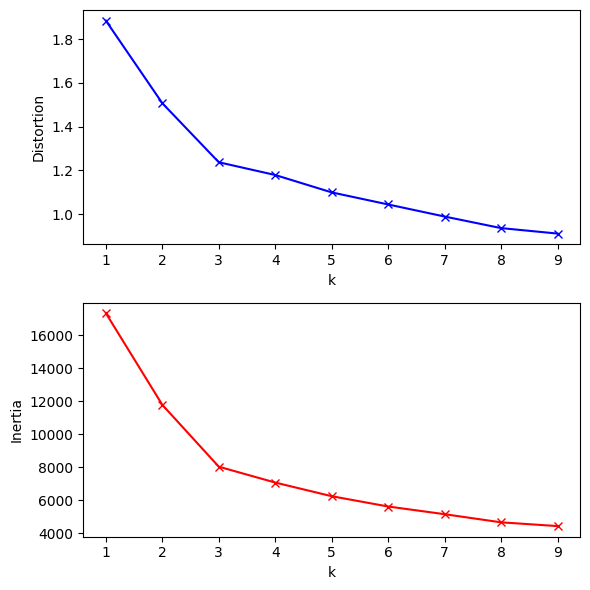

In [96]:
X = rfm_sdf[['recency','frequency','monetary_value','tenure']].values

# Check zero rows in matrix
zero_rows = np.linalg.norm(X, axis=1) == 0
print("Number of rows of zeros:" + str(X[zero_rows].shape[1]))

# Kmeans clustering - Elbow method
distortions = []
inertias = []

K = range(1,10)

for k in K:
    kmeansModels = KMeans(n_clusters=k).fit(X)
    distortions.append(
        sum(np.min(
            cdist(X, kmeansModels.cluster_centers_, 'euclidean'), axis=1)
            ) / X.shape[0]
        )
    inertias.append(kmeansModels.inertia_)
    
# Plot elbow method
fig, ax = plt.subplots(2,1, figsize=(6,6))
ax[0].plot(K, distortions, 'bx-')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Distortion')

ax[1].plot(K, inertias, 'rx-')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Inertia')

plt.tight_layout()
plt.show()


Both plots suggest diminishing improvements after four clusters.  

### Clustering Results

A four cluster Kmeans algorithm is applied to the data. The resulting 3D plot hued with clusters show clear separation. 

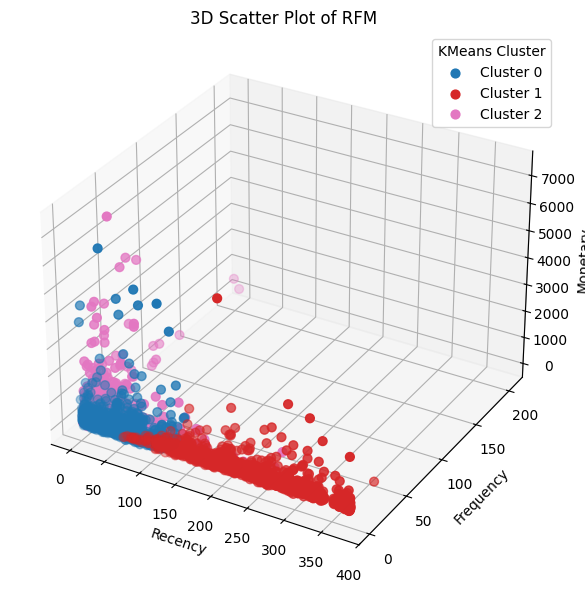

In [102]:
# KMeans clustering
kmeansModel = KMeans(n_clusters=3,random_state=42).fit(X)
rfm_sdf['KMeans_Cluster'] = kmeansModel.labels_

# Merge to original dataframe
rfm_clustered_df = rfm_df.merge(
    right=rfm_sdf[['CustomerID','KMeans_Cluster']],
    on='CustomerID',
    how='left'
)

# Visualise in orginal scaling
plot_filter = (rfm_clustered_df['monetary_value']<10000)
plot_3D_rfm(rfm_clustered_df[plot_filter])

The plot above implies the following grouping:
- cluster 0: High value active Customers  
- cluster 1: Churned customers
- cluster 2: New Customers
- cluster 3: Low value active customers

In [103]:
# Save RFM ith Kmeans clusters
OUT_DIR = '../data/analysis'
rfm_clustered_df.to_parquet(OUT_DIR +"/rfm_cluster.parquet", index=False)